In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    matthews_corrcoef,
    precision_recall_curve,
    auc,
    confusion_matrix,
    classification_report
)

from imblearn.over_sampling import SMOTE

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [3]:
df = pd.read_csv("parkinsons.data")
df = df.drop(['name'], axis=1)

X = df.drop('status', axis=1).values
y = df['status'].values

print("Original Class Distribution:")
pd.Series(y).value_counts()

Original Class Distribution:


1    147
0     48
Name: count, dtype: int64

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [5]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("After SMOTE:")
pd.Series(y_train_smote).value_counts()

After SMOTE:


0    118
1    118
Name: count, dtype: int64

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

In [7]:
print("Training PCA-SVM...")

pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 0.1, 0.01, 0.001]
}

grid_pca = GridSearchCV(
    SVC(kernel='rbf', probability=True),
    param_grid,
    cv=5
)

grid_pca.fit(X_train_pca, y_train_smote)
svm_pca = grid_pca.best_estimator_

y_pred_pca = svm_pca.predict(X_test_pca)
y_prob_pca = svm_pca.predict_proba(X_test_pca)[:, 1]

Training PCA-SVM...


In [8]:
print("Training Sparse Autoencoder...")

class SparseAutoencoder(nn.Module):
    def __init__(self, input_dim):
        super(SparseAutoencoder, self).__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 16)
        )

        self.decoder = nn.Sequential(
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, input_dim)
        )

    def forward(self, x):
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)
        return reconstructed, latent


input_dim = X_train_scaled.shape[1]
model = SparseAutoencoder(input_dim)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
l1_lambda = 1e-5   # tuned sparsity

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
train_dataset = TensorDataset(X_train_tensor, X_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

epochs = 150

for epoch in range(epochs):
    total_loss = 0

    for data_batch, _ in train_loader:
        optimizer.zero_grad()

        reconstructed, latent = model(data_batch)

        mse_loss = criterion(reconstructed, data_batch)
        l1_loss = torch.mean(torch.abs(latent))

        loss = mse_loss + l1_lambda * l1_loss

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Training Sparse Autoencoder...
Epoch 20, Loss: 1.9012
Epoch 40, Loss: 0.7622
Epoch 60, Loss: 0.4998
Epoch 80, Loss: 0.3811
Epoch 100, Loss: 0.3130
Epoch 120, Loss: 0.2567
Epoch 140, Loss: 0.2125


In [9]:
model.eval()

with torch.no_grad():
    X_train_sae = model.encoder(
        torch.tensor(X_train_scaled, dtype=torch.float32)
    ).numpy()

    X_test_sae = model.encoder(
        torch.tensor(X_test_scaled, dtype=torch.float32)
    ).numpy()

In [10]:
print("Training SAE-SVM...")

grid_sae = GridSearchCV(
    SVC(kernel='rbf', probability=True),
    param_grid,
    cv=5
)

grid_sae.fit(X_train_sae, y_train_smote)
svm_sae = grid_sae.best_estimator_

y_pred_sae = svm_sae.predict(X_test_sae)
y_prob_sae = svm_sae.predict_proba(X_test_sae)[:, 1]

Training SAE-SVM...


In [11]:
def evaluate_model(name, y_test, y_pred, y_prob):

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)

    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(recall, precision)

    print(f"----- {name} Results -----")
    print("Accuracy:", acc)
    print("F1 Score:", f1)
    print("MCC:", mcc)
    print("PR AUC:", pr_auc)
    print()
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print()
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print()

    return precision, recall

In [12]:
precision_pca, recall_pca = evaluate_model(
    "PCA-SVM", y_test, y_pred_pca, y_prob_pca
)

precision_sae, recall_sae = evaluate_model(
    "SAE-SVM", y_test, y_pred_sae, y_prob_sae
)

----- PCA-SVM Results -----
Accuracy: 0.8974358974358975
F1 Score: 0.9285714285714286
MCC: 0.7535992817105361
PR AUC: 0.9818268148383844

Confusion Matrix:
[[ 9  1]
 [ 3 26]]

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.90      0.82        10
           1       0.96      0.90      0.93        29

    accuracy                           0.90        39
   macro avg       0.86      0.90      0.87        39
weighted avg       0.91      0.90      0.90        39


----- SAE-SVM Results -----
Accuracy: 0.8974358974358975
F1 Score: 0.9259259259259259
MCC: 0.7847060257179307
PR AUC: 0.9854077287592595

Confusion Matrix:
[[10  0]
 [ 4 25]]

Classification Report:
              precision    recall  f1-score   support

           0       0.71      1.00      0.83        10
           1       1.00      0.86      0.93        29

    accuracy                           0.90        39
   macro avg       0.86      0.93      0.88        39
we

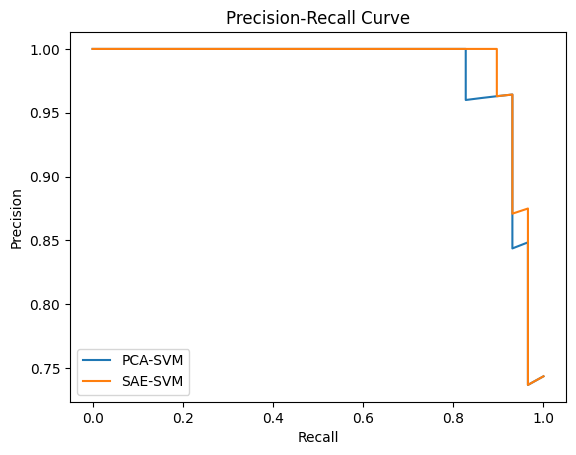

In [13]:

plt.figure()
plt.plot(recall_pca, precision_pca, label="PCA-SVM")
plt.plot(recall_sae, precision_sae, label="SAE-SVM")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()